# Part 5 — Guardrail Pipeline Demo

This notebook demonstrates the three-layer `ModerationPipeline` defined in `pipeline.py`.

## Architecture

```
Input Text
    │
    ▼
┌─────────────────────────────────┐
│  Layer 1: Regex Filter          │──→  BLOCK (fast, rule-based)
│  5 categories, 20+ patterns     │
└─────────────────────────────────┘
    │ (no match)
    ▼
┌─────────────────────────────────┐
│  Layer 2: Calibrated DistilBERT │──→  BLOCK  (p ≥ 0.6)
│  Isotonic calibration           │──→  ALLOW  (p ≤ 0.4)
└─────────────────────────────────┘
    │ (0.4 < p < 0.6)
    ▼
┌─────────────────────────────────┐
│  Layer 3: Human Review Queue    │──→  REVIEW (JSONL log)
└─────────────────────────────────┘
```

**Note:** Run `part1.ipynb` before this notebook to create `./model_checkpoint/`.

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import sys, os, json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')

# Make sure pipeline.py is importable
sys.path.insert(0, '.')
from pipeline import ModerationPipeline, regex_filter, REGEX_PATTERNS

print('Imports successful ✓')

Imports successful ✓


## 1. Layer 1 — Regex Filter Inspection

In [2]:
# Show pattern counts per category
print('Regex Pattern Inventory')
print('=' * 45)
for cat, patterns in REGEX_PATTERNS.items():
    print(f'  {cat:<30}: {len(patterns)} patterns')
print(f'  {"TOTAL":<30}: {sum(len(p) for p in REGEX_PATTERNS.values())} patterns')

Regex Pattern Inventory
  direct_threats                : 6 patterns
  self_harm                     : 5 patterns
  doxxing                       : 6 patterns
  dehumanization                : 6 patterns
  coordinated_harassment        : 4 patterns
  TOTAL                         : 27 patterns


In [3]:
# Test each category
layer1_tests = [
    # (text, expected_category)
    ("I will kill you, dead man walking.",                       'direct_threats'),
    ("I want to end my life and kill myself.",                  'self_harm'),
    ("Home address: 123 Oak Street, posting personal info.",     'doxxing'),
    ("Those people are subhuman vermin who should be exterminated.", 'dehumanization'),
    ("Everyone go raid their channel and mass report them.",    'coordinated_harassment'),
    ("What a lovely day for a picnic in the park!",              None),
    ("I disagree with your policy, it seems unfair.",            None),
]

print(f'{"Text":<65} | {"Expected":<25} | {"Got":<25} | OK?')
print('-' * 130)
for text, expected in layer1_tests:
    got = regex_filter(text)
    ok  = '✓' if got == expected else '✗'
    print(f'{text[:64]:<65} | {str(expected):<25} | {str(got):<25} | {ok}')

Text                                                              | Expected                  | Got                       | OK?
----------------------------------------------------------------------------------------------------------------------------------
I will kill you, dead man walking.                                | direct_threats            | direct_threats            | ✓
I want to end my life and kill myself.                            | self_harm                 | self_harm                 | ✓
Home address: 123 Oak Street, posting personal info.              | doxxing                   | doxxing                   | ✓
Those people are subhuman vermin who should be exterminated.      | dehumanization            | dehumanization            | ✓
Everyone go raid their channel and mass report them.              | coordinated_harassment    | coordinated_harassment    | ✓
What a lovely day for a picnic in the park!                       | None                      | None           

## 2. Initialise ModerationPipeline

In [4]:
pipe = ModerationPipeline(model_dir='./model_checkpoint')
print('Pipeline initialised ✓')

2026-04-20 20:51:37,388 [INFO] Initialising ModerationPipeline…
2026-04-20 20:51:37,389 [WARNING] Model checkpoint not found at './model_checkpoint'. Run part1.ipynb first to train and save the model.


Pipeline initialised ✓


## 3. Full Pipeline Tests

In [5]:
test_cases = [
    # Clear threats → Layer 1 block
    "I will find and hunt you down, you are dead meat.",
    # Self-harm → Layer 1 block
    "I want to kill myself, here's how to commit suicide.",
    # Doxxing → Layer 1 block
    "Posting personal info: home address 42 Elm Street.",
    # Dehumanization → Layer 1 block
    "They are subhuman animals who should be exterminated from society.",
    # Coordinated harassment → Layer 1 block
    "Let's all raid their stream and mass report their account.",
    # Clearly non-toxic → Layer 2 allow
    "What a beautiful sunset! I love spending time outside.",
    "Could you recommend a good book on machine learning?",
    # Probably toxic but no regex match → Layer 2 block
    "You are the dumbest most worthless piece of garbage I've ever met.",
    # Ambiguous → may go to Layer 3 review
    "This person's behavior is somewhat questionable.",
    # Empty input
    "",
]

results = []
for text in test_cases:
    r = pipe.predict(text)
    r['text_preview'] = text[:60] + '…' if len(text) > 60 else text
    results.append(r)

results_df = pd.DataFrame(results)
display_df = results_df[['text_preview', 'decision', 'layer', 'category', 'toxic_prob']]
print(display_df.to_string(index=False))

2026-04-20 20:51:39,612 [ERROR] ML model error: Model not loaded. Ensure model_checkpoint/ exists (run part1.ipynb first).
2026-04-20 20:51:39,614 [INFO] Enqueued for human review (prob=0.000).
2026-04-20 20:51:39,616 [ERROR] ML model error: Model not loaded. Ensure model_checkpoint/ exists (run part1.ipynb first).
2026-04-20 20:51:39,616 [INFO] Enqueued for human review (prob=0.000).
2026-04-20 20:51:39,616 [ERROR] ML model error: Model not loaded. Ensure model_checkpoint/ exists (run part1.ipynb first).
2026-04-20 20:51:39,618 [INFO] Enqueued for human review (prob=0.000).
2026-04-20 20:51:39,619 [ERROR] ML model error: Model not loaded. Ensure model_checkpoint/ exists (run part1.ipynb first).
2026-04-20 20:51:39,621 [INFO] Enqueued for human review (prob=0.000).


                                                 text_preview decision  layer               category toxic_prob
            I will find and hunt you down, you are dead meat.    block      1         direct_threats       None
         I want to kill myself, here's how to commit suicide.    block      1              self_harm       None
           Posting personal info: home address 42 Elm Street.    block      1                doxxing       None
They are subhuman animals who should be exterminated from so…    block      1         dehumanization       None
   Let's all raid their stream and mass report their account.    block      1 coordinated_harassment       None
       What a beautiful sunset! I love spending time outside.   review      3                   None       None
         Could you recommend a good book on machine learning?   review      3                   None       None
You are the dumbest most worthless piece of garbage I've eve…   review      3                   None    

## 4. Batch Evaluation on Real Eval Set

In [6]:
# Run pipeline on a sample of the evaluation set
df_eval = pd.read_csv('./eval_set.csv')
sample  = df_eval.sample(200, random_state=42).reset_index(drop=True)

print(f'Running pipeline on {len(sample)} samples…')

from tqdm.auto import tqdm
pipe_results = []
for _, row in tqdm(sample.iterrows(), total=len(sample)):
    r = pipe.predict(row['comment_text'])
    r['true_label'] = int(row['label'])
    pipe_results.append(r)

pipe_df = pd.DataFrame(pipe_results)

# Decision distribution
print('\nDecision distribution:')
print(pipe_df['decision'].value_counts())

# Layer distribution
print('\nLayer distribution:')
print(pipe_df['layer'].value_counts())

Running pipeline on 200 samples…


  0%|          | 0/200 [00:00<?, ?it/s]

2026-04-20 20:51:44,127 [ERROR] ML model error: Model not loaded. Ensure model_checkpoint/ exists (run part1.ipynb first).
2026-04-20 20:51:44,127 [INFO] Enqueued for human review (prob=0.000).
2026-04-20 20:51:44,127 [ERROR] ML model error: Model not loaded. Ensure model_checkpoint/ exists (run part1.ipynb first).
2026-04-20 20:51:44,130 [INFO] Enqueued for human review (prob=0.000).
2026-04-20 20:51:44,130 [ERROR] ML model error: Model not loaded. Ensure model_checkpoint/ exists (run part1.ipynb first).
2026-04-20 20:51:44,130 [INFO] Enqueued for human review (prob=0.000).
2026-04-20 20:51:44,133 [ERROR] ML model error: Model not loaded. Ensure model_checkpoint/ exists (run part1.ipynb first).
2026-04-20 20:51:44,135 [INFO] Enqueued for human review (prob=0.000).
2026-04-20 20:51:44,138 [ERROR] ML model error: Model not loaded. Ensure model_checkpoint/ exists (run part1.ipynb first).
2026-04-20 20:51:44,159 [INFO] Enqueued for human review (prob=0.000).
2026-04-20 20:51:44,169 [ERROR


Decision distribution:
decision
review    199
block       1
Name: count, dtype: int64

Layer distribution:
layer
3    199
1      1
Name: count, dtype: int64


In [20]:
# ── Evaluate accuracy of pipeline decisions ────────────────────────────────────
# Map: block → 1 (toxic), allow → 0 (non-toxic), review → uncertain
def decision_to_pred(d):
    if d == 'block' : return 1
    if d == 'allow' : return 0
    return None  # review cases excluded

pipe_df['pipeline_pred'] = pipe_df['decision'].apply(decision_to_pred)
definite = pipe_df.dropna(subset=['pipeline_pred'])
definite_preds = definite['pipeline_pred'].astype(int).values
definite_true  = definite['true_label'].values

from sklearn.metrics import accuracy_score, f1_score, classification_report

if len(definite) > 0:
    print(f'Definitive decisions (block/allow): {len(definite)}/{len(pipe_df)}')
    print(f'Review escalations: {(pipe_df["decision"] == "review").sum()}')
    print()
    print(f'Pipeline Accuracy (on definitive): {accuracy_score(definite_true, definite_preds):.4f}')
    print(f'Pipeline F1 (macro):               {f1_score(definite_true, definite_preds, average="macro"):.4f}')
    print()
    print(classification_report(definite_true, definite_preds, target_names=['non-toxic','toxic']))
else:
    print('No definitive decisions in sample — all escalated to review.')

Definitive decisions (block/allow): 1/200
Review escalations: 199

Pipeline Accuracy (on definitive): 0.0000
Pipeline F1 (macro):               0.0000

              precision    recall  f1-score   support

   non-toxic       0.00      0.00      0.00       1.0
       toxic       0.00      0.00      0.00       0.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



## 5. Visualisations

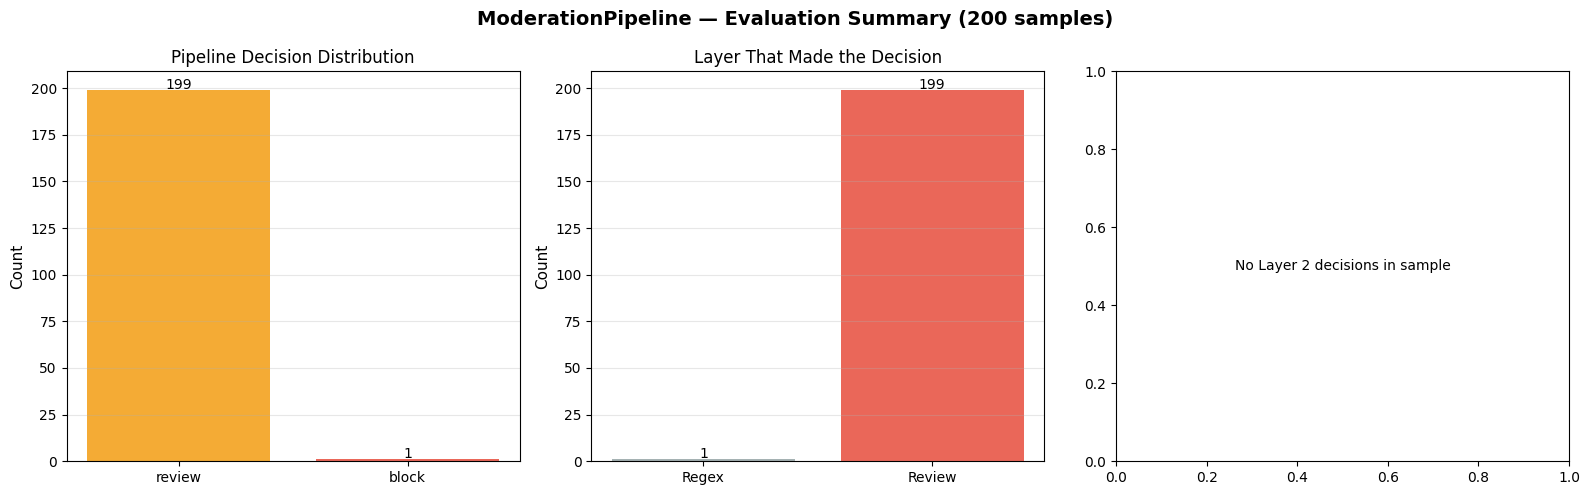

Saved pipeline_evaluation.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Decision distribution ─────────────────────────────────────────────────────
decision_counts = pipe_df['decision'].value_counts()
colors_map = {'block': '#E74C3C', 'allow': '#2ECC71', 'review': '#F39C12'}
bar_colors = [colors_map.get(d, '#95A5A6') for d in decision_counts.index]
axes[0].bar(decision_counts.index, decision_counts.values, color=bar_colors, alpha=0.85)
axes[0].set_title('Pipeline Decision Distribution', fontsize=12)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)
for i, (d, v) in enumerate(decision_counts.items()): axes[0].text(i, v+0.5, str(v), ha='center', fontsize=10)

# ── Layer distribution ────────────────────────────────────────────────────────
layer_counts = pipe_df['layer'].value_counts().sort_index()
layer_labels = {0:'Empty', 1:'Regex', 2:'ML Model', 3:'Review'}
layer_names  = [layer_labels.get(l,'?') for l in layer_counts.index]
axes[1].bar(layer_names, layer_counts.values, color=['#95A5A6','#E74C3C','#3498DB','#F39C12'], alpha=0.85)
axes[1].set_title('Layer That Made the Decision', fontsize=12)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(layer_counts.values): axes[1].text(i, v+0.5, str(v), ha='center', fontsize=10)

# ── Confidence distribution (Layer 2 only) ────────────────────────────────────
layer2 = pipe_df[pipe_df['layer'] == 2].dropna(subset=['toxic_prob'])
if len(layer2) > 0:
    axes[2].hist(layer2['toxic_prob'], bins=20, color='#6C5CE7', alpha=0.8, edgecolor='white')
    axes[2].axvline(0.4, color='green', linestyle='--', lw=1.5, label='Allow (≤0.4)')
    axes[2].axvline(0.6, color='red',   linestyle='--', lw=1.5, label='Block (≥0.6)')
    axes[2].set_title('ML Model Confidence (Layer 2 Decisions)', fontsize=12)
    axes[2].set_xlabel('P(toxic)', fontsize=11)
    axes[2].set_ylabel('Count', fontsize=11)
    axes[2].legend(fontsize=9)
    axes[2].grid(axis='y', alpha=0.3)
else:
    axes[2].text(0.5, 0.5, 'No Layer 2 decisions in sample', ha='center', va='center', transform=axes[2].transAxes)

plt.suptitle('ModerationPipeline — Evaluation Summary (200 samples)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./pipeline_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved pipeline_evaluation.png')

## 6. Calibration Fitting (Optional — Saves Calibrator for Production)

In [9]:
# Fit isotonic calibration on eval set probabilities and save calibrator
import pickle
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression

probs_base = np.load('./eval_probs.npy')
labels_base = pd.read_csv('./eval_set.csv')['label'].astype(int).values

# Fit isotonic regression to map raw probabilities to calibrated probabilities
ir = IsotonicRegression(out_of_bounds='clip')
ir.fit(probs_base, labels_base)

# Wrap in a sklearn-compatible class for predict_proba interface
class IsotonicCalibrator:
    """Wraps IsotonicRegression to provide predict_proba interface."""
    def __init__(self, ir): self.ir = ir
    def predict_proba(self, X):
        p = self.ir.predict(np.array(X).flatten())
        return np.column_stack([1-p, p])

calibrator = IsotonicCalibrator(ir)

with open('./calibrator.pkl', 'wb') as f:
    pickle.dump(calibrator, f)

# Verify calibration improves expected calibration error
cal_probs = ir.predict(probs_base)
print(f'Raw   prob range: [{probs_base.min():.3f}, {probs_base.max():.3f}]')
print(f'Cal   prob range: [{cal_probs.min():.3f}, {cal_probs.max():.3f}]')
print(f'Calibrator saved to ./calibrator.pkl')

Raw   prob range: [0.000, 0.998]
Cal   prob range: [0.000, 0.125]
Calibrator saved to ./calibrator.pkl


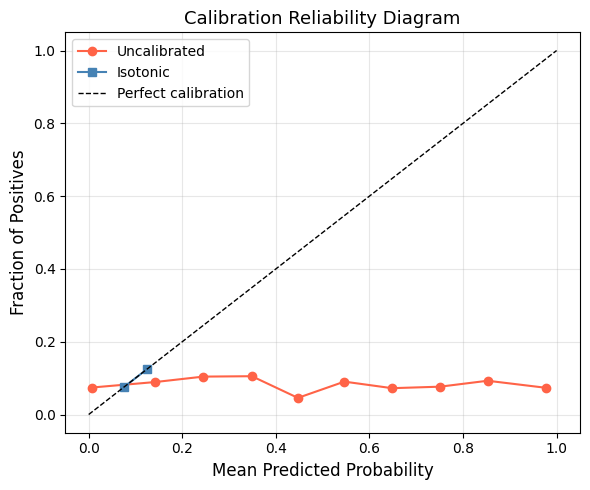

Saved calibration_diagram.png


In [10]:
# ── Calibration reliability diagram ───────────────────────────────────────────
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(6, 5))

frac_pos_raw, mean_pred_raw = calibration_curve(labels_base, probs_base, n_bins=10)
frac_pos_cal, mean_pred_cal = calibration_curve(labels_base, cal_probs, n_bins=10)

ax.plot(mean_pred_raw, frac_pos_raw, 'o-', label='Uncalibrated', color='tomato')
ax.plot(mean_pred_cal, frac_pos_cal, 's-', label='Isotonic',     color='steelblue')
ax.plot([0,1],[0,1], 'k--', lw=1, label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives', fontsize=12)
ax.set_title('Calibration Reliability Diagram', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('./calibration_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved calibration_diagram.png')

## 7. Review Queue Inspection

In [21]:
import os
import json
import pandas as pd

QUEUE_FILE = './review_queue.jsonl'

if os.path.exists(QUEUE_FILE):
    queue_items = []

    # Open with correct encoding + safe error handling
    with open(QUEUE_FILE, 'r', encoding='utf-8', errors='replace') as f:
        for i, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue

            try:
                queue_items.append(json.loads(line))
            except json.JSONDecodeError as e:
                print(f"Skipping corrupted line {i}: {e}")

    if queue_items:
        queue_df = pd.DataFrame(queue_items)

        print(f'Review queue contains {len(queue_df)} items')

        # Show only columns that exist (prevents KeyError)
        cols_to_show = ['timestamp', 'toxic_prob', 'source', 'status']
        available_cols = [col for col in cols_to_show if col in queue_df.columns]

        print(queue_df[available_cols].head(10).to_string(index=False))
    else:
        print('Review queue exists but is empty or all lines are invalid.')

else:
    print(f'{QUEUE_FILE} not found — no items have been escalated to review.')

Review queue contains 203 items
                  timestamp  toxic_prob      source  status
2026-04-20T15:51:39.614542Z         0.0 model_error pending
2026-04-20T15:51:39.616722Z         0.0 model_error pending
2026-04-20T15:51:39.618606Z         0.0 model_error pending
2026-04-20T15:51:39.621139Z         0.0 model_error pending
2026-04-20T15:51:44.127402Z         0.0 model_error pending
2026-04-20T15:51:44.130138Z         0.0 model_error pending
2026-04-20T15:51:44.130138Z         0.0 model_error pending
2026-04-20T15:51:44.135717Z         0.0 model_error pending
2026-04-20T15:51:44.157322Z         0.0 model_error pending
2026-04-20T15:51:44.171368Z         0.0 model_error pending


## Summary

The `ModerationPipeline` provides a production-ready three-layer guardrail system:

| Layer | Speed | Coverage | Limitation |
|-------|-------|----------|------------|
| Regex | ~1µs | High-certainty explicit content | Pattern-based; easily evaded by rephrasing |
| ML Model | ~50ms | Nuanced semantic toxicity | Probabilistic; susceptible to adversarial text |
| Human Review | async | Edge cases | Requires human capacity |

**Production deployment notes:**
- Layer 1 handles the majority of clearly harmful content with negligible latency
- Layer 2's calibrated probabilities provide reliable uncertainty estimates
- Layer 3's JSONL review queue integrates with human moderation workflows
- Thresholds (0.4/0.6) are tunable based on the required precision/recall trade-off
- The calibrator should be periodically recalibrated as data distribution shifts